# Notebook 3: Continuous-space interacting bosonic particles

This tutorial heavily builds upon that written by Gabriel Pescia for the official NetKet documentation.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Z-Denis/cecam-nqs/blob/main/notebooks/03_continuous_space_bosons.ipynb)

If you are running locally, start JupyterLab with:

```bash
uv run jupyter lab
```

In [1]:
# IF AND ONLY IF you are running this notebook on Google Colab:

# On a CPU runtime, uncomment and run:
# %pip uninstall -y jax jaxlib jax-cuda12-plugin jax-cuda12-pjrt
# %pip install -q "jax==0.10.1" "jaxlib==0.10.1"
# %pip install -q git+https://github.com/Z-Denis/cecam-nqs.git

# On a T4 GPU runtime, uncomment and run:
# %pip install -q "jax[cuda12]==0.10.1"
# %pip install -q git+https://github.com/Z-Denis/cecam-nqs.git

In this notebook, we explore how variational Monte Carlo can be applied to bosons in continuous space, from a simple permutation-invariant Gaussian Ansatz to a neural-network wavefunction respecting the same symmetry.

Throughout this notebook, we consider $N$ identical bosons in two spatial dimensions, with particle coordinates

$$
\mathbf X = (\mathbf x_1,\ldots,\mathbf x_N), \qquad \mathbf x_i\in\mathbb R^2 .
$$

## 1. Bosons in a two-dimensional harmonic trap

As a first example, we consider $N$ bosons confined by a two-dimensional harmonic trap,

$$ 
H = -\frac12 \sum_{i=1}^{N} \nabla_{\mathbf x_i}^2 + \frac12 \sum_{i=1}^{N} |\mathbf x_i|^2.
$$

### A bosonic Gaussian Ansatz

A general centred Gaussian wavefunction can be written as

$$
\log \psi(\mathbf X) = -\frac12 \sum_{i,j=1}^N \mathbf x_i^\top {\bf A}_{ij}\mathbf x_j .
$$

For identical bosons, the wavefunction must be invariant under any permutation of particle labels,

$$
\psi(\mathbf x_1,\ldots,\mathbf x_N) = \psi(\mathbf x_{\pi(1)},\ldots,\mathbf x_{\pi(N)}).
$$

This requires ${\bf A}_{\pi(i)\pi(j)} = {\bf A}_{ij}$ for every permutation $\pi$. Therefore all diagonal blocks must be identical and all off-diagonal blocks must be identical: ${\bf A}_{ii}={\bf A}_{\rm diag}$, ${\bf A}_{ij\neq i}={\bf A}_{\rm off}$. The most general bosonic Gaussian therefore takes the form

$$ 
-\frac12 \left[ \sum_i \mathbf x_i^\top {\bf A}_{\mathrm{diag}} \mathbf x_i + \sum_{i\neq j} \mathbf x_i^\top {\bf A}_{\mathrm{off}} \mathbf x_j \right].
$$

We further restrict ourselves to isotropic correlations and choose these blocks to be proportional to the identity, $A_{\rm diag}=a\,\mathbb I_2$, and $A_{\rm off}=b\,\mathbb I_2$.

The most general permutation-invariant and rotation-invariant Gaussian is therefore

$$
\log\psi(\mathbf X) = -\frac12 \left[ a\sum_i |\mathbf x_i|^2 + b\sum_{i\neq j} \mathbf x_i\cdot\mathbf x_j \right].
$$

Using $\sum_{i\neq j}\mathbf x_i\cdot\mathbf x_j = \left|\sum_i\mathbf x_i\right|^2 - \sum_i |\mathbf x_i|^2$ , and defining the centre of mass $\mathbf X_{\rm cm} = \frac1N\sum_i\mathbf x_i$, we can rewrite the Ansatz as

$$
\log\psi(\mathbf X) = -\frac12 \left[ \alpha\sum_i|\mathbf x_i-\mathbf X_{\rm cm}|^2 + \gamma N |\mathbf X_{\rm cm}|^2\right],
$$

where the two parameters $\alpha$ and $\gamma$ control the size of the relative cloud and the width of the centre-of-mass motion, respectively. Note how the symmetries of the problem reduced the number of parameters from $4N$ to $2$ (actually to $1$).

### Defining the Hilbert space

The first ingredient of a continuous-space simulation is the Hilbert space. In NetKet, a particle Hilbert space is specified by the number of particles, the geometry of the simulation domain, and the boundary conditions. Here, we consider $N=10$ bosons moving in free two-dimensional space.

In [2]:
import netket as nk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

N = 10  # number of particles
dim = 2   # number of spatial dimensions

geo = nk.experimental.geometry.FreeSpace(d=dim)
hi = nk.experimental.hilbert.Particle(N=N, geometry=geo)

∣NK⟩ Tip: 😍 Love? 😡 Hate? these tips? Let us know at https://forms.gle/ej8eDGFRu2mww5mQ9

We now define the model described above by inheriting from `flax.linen.Module`

In [3]:
import flax.linen as nn

class BosonicGaussian(nn.Module):
    """Permutation-invariant Gaussian wavefunction for trapped bosons."""
    dim: int
    
    @nn.compact
    def __call__(self, X):
        # NetKet passes X with shape (..., N * dim)
        X = X.reshape(*X.shape[:-1], N, self.dim) # (..., N, dim)

        log_alpha = self.param(
            "log_alpha",
            nn.initializers.constant(jnp.log(0.5)),
            (),
        )
        log_gamma = self.param(
            "log_gamma",
            nn.initializers.constant(jnp.log(0.5)),
            (),
        )

        alpha = jnp.exp(log_alpha)
        gamma = jnp.exp(log_gamma)

        X_cm = jnp.mean(X, axis=-2, keepdims=True)
        X_rel = X - X_cm

        rel_size = jnp.sum(X_rel**2, axis=(-2, -1))
        cm_size = jnp.sum(X_cm[..., 0, :]**2, axis=-1)

        return -0.5 * (
            alpha * rel_size
            + gamma * N * cm_size
        )

### Hamiltonian, sampler, and variational state

Having defined the Hilbert space and the variational Ansatz, we can now construct a complete variational Monte Carlo calculation. This requires three additional ingredients:

- the Hamiltonian $H$ defining the physical problem;
- a Monte Carlo sampler to generate configurations from $|\psi(\mathbf X)|^2$;
- a variational state hosting the model and the sampler.

In this case, we define the two-dimensional harmonic potential, $V(\mathbf X)=\frac12\sum_i |\mathbf x_i|^2$, and use a Gaussian Metropolis sampler to explore configuration space. Note how the form of the kinetic energy is always the same and only depends on the mass of the particles:

$$
    \mathcal{T} = -\sum_{i=1}^N \frac{1}{2m_i}\frac{\partial}{\partial \mathbf{x}_i} \cdot \frac{\partial}{\partial \mathbf{x}_i} = -\sum_{i=1}^N \sum_{\mu=1}^d \frac{1}{2m_i}\frac{\partial^2}{\partial x_{i\mu}^2}
$$

In practice, we need obtain the kinetic energy as a standard expectation value. This can be done by writing

$$
E_{\mathrm{kin}} = -\sum_{i=1}^N \sum_{\mu=1}^d \frac{1/2m_i}{\langle\psi_{\bf\theta}\vert\psi_{\bf\theta}\rangle}\int\mathrm{d}{\bf X} \psi_{\bf\theta}^\star({\bf X})\,\frac{\partial^2}{\partial x_{i\mu}^2}\,\psi_{\bf\theta}({\bf X}) = \int\mathrm{d}{\bf X} p_{\bf \theta}({\bf X})\sum_{i=1}^N \sum_{\mu=1}^d \frac{-1}{2 m_i}\bigl[(\partial_{x_{i\mu}}\ln\psi_{\mathbf{\theta}}({\bf X}))^2 + \partial_{x_{i\mu}}^2\ln\psi_{\mathbf{\theta}}({\bf X})\bigr],
$$

which can now be estimated through Markov chain Monte Carlo.

NetKet provides a full implementation of this estimator relying on JAX autodifferentiation capabilities. Note that some care must be taken when computing the double derivative numerically as to reach optimal efficiency.


In the following we initialize the kinetic energy operator for particles of masses $ m_i=1 $ (one could also provide a tuple of different masses for each particle).


In [4]:
def harmonic_potential(X, dim):
    """2D harmonic confinement."""
    X = X.reshape(N, dim)
    return 0.5 * jnp.sum(X**2)

# Potential term
V = nk.operator.PotentialEnergy(hi, lambda X: harmonic_potential(X, dim))
# Kinetic term
T = nk.operator.KineticEnergy(hi, mass=1.0)
# Total Hamiltonian
H = T + V

# Metropolis-based sampler with isotropic Gaussian updates
sampler = nk.sampler.MetropolisGaussian(
    hi,
    sigma=0.5,
    n_chains=32,
)

# Variational quantum state
vstate = nk.vqs.MCState(
    sampler=sampler,
    model=BosonicGaussian(dim=dim),
    n_samples=4096,
)

### Sampling configurations

Before optimising the wavefunction, let us inspect the particle configurations generated by the initial Ansatz. Each Monte Carlo sample corresponds to a full flattened many-body configuration $X=(\mathbf x_1,\ldots,\mathbf x_N)$, which we can visualise as $N$ points in the two-dimensional plane.

In [5]:
samples = vstate.sample()

print(samples.shape)

(32, 128, 20)


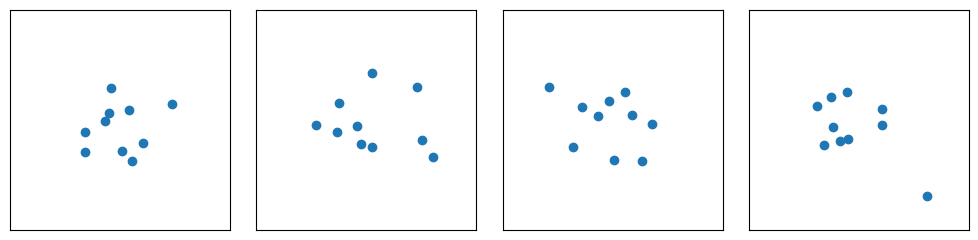

In [6]:
samples = samples.reshape(-1, N, dim)

fig, axes = plt.subplots(1, 4, figsize=(10, 2.5), sharex=True, sharey=True)

for ax, X in zip(axes, samples[:4]):
    ax.scatter(X[:, 0], X[:, 1])
    ax.set_aspect("equal")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

We can now estimate the variational energy of the initial Gaussian wavefunction. At this stage the parameters have not been optimised yet, so this only gives us a baseline before running VMC.

In [7]:
print(vstate.parameters)

E0 = vstate.expect(H)
print(E0)

{'log_alpha': Array(-0.69314718, dtype=float64), 'log_gamma': Array(-0.69314718, dtype=float64)}
12.557 ± 0.067 [σ²=5.7e+00, R̂=1.022]


### Optimising the Gaussian

We now minimise the variational energy. The optimisation should drive both parameters towards $\alpha=\gamma=1$.

In [8]:
optimizer = nk.optimizer.Sgd(learning_rate=0.05)

gs = nk.driver.VMC(
    H,
    optimizer,
    variational_state=vstate,
)

log = nk.logging.RuntimeLog()

gs.run(
    n_iter=100,
    out=log,
)

print(vstate.parameters)

E = vstate.expect(H)
print(E)

  0%|                                                  | 0/100 [00:00<?, ?it/s]

{'log_alpha': Array(1.70245399e-05, dtype=float64), 'log_gamma': Array(-0.00406861, dtype=float64)}
10.00007 ± 0.00010 [σ²=1.8e-05, R̂=1.017]


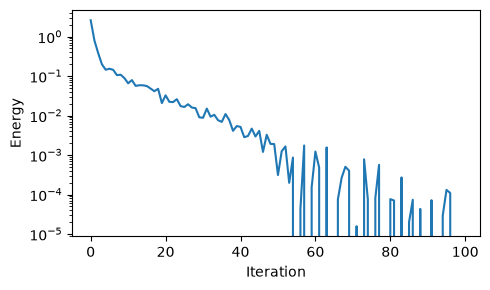

In [9]:
energy = log.data["Energy"].Mean

energy_exact = N * dim / 2
plt.figure(figsize=(5, 3))
plt.semilogy(energy - energy_exact)
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.tight_layout()

## 2. Interacting bosons in a periodic box

In the following, we use a neural-network architecture called *Deep Sets* to solve the more interesting case of bosons interacting via a repulsive Gaussian interaction:

$$
\epsilon  \sum_{i<j} \exp\left[-|\mathbf{x}_{ij}|^2\right].
$$

We study the bulk of the system by confining it into a box of length $L$ with periodic boundary conditions. In this extended system we define the particle density as $ D = N/L^d $ and we study the case $ D=1 $ for $ N=20 $ particles in $ d=1 $ dimensions with $ \epsilon = 2 $. To account for the periodicity we use the minimum-image convention when evaluating the potential energy of the system.

The Deep Sets architecture we will use is defined as:

$$
\mathrm{DS}(\mathbf{X}) = \rho\left[\sum_{i,j} \phi \left( \mathbf{y}_{ij}\right) \right]
$$

where the functions $ \phi $ and $ \rho $ are parametrised by simple feed-forward neural network with a GeLu activation function with one hidden layer.

Since the particles live on a periodic ring, we do not use the raw displacement $\mathbf{x}_{ij}$ as input. Instead, we represent it through the periodic features

$$
\mathbf{y}_{ij} = \left( \sin\frac{2\pi}{L}\mathbf{x}_{ij}, \cos\frac{2\pi}{L}\mathbf{x}_{ij}\right).
$$

This representation contains the same information as the displacement modulo $L$, while making the periodic geometry explicit and ensuring that points near the boundaries of the box are treated as nearby by the neural network.

See [PRR _4_, 023138 (2022)](https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.4.023138) for more information.

In [10]:
def minimum_distance(x, N, sdim):
    """Computes distances between particles using minimum image convention"""
    x = x.reshape(-1, N, sdim)
    idx = jnp.triu_indices(N, 1)
    distances = (-x[..., None, :, :] + x[..., :, None, :])[..., idx[0], idx[1], :]
    # minimum image convention
    distances = jnp.remainder(distances + L / 2.0, L) - L / 2.0
    return jnp.linalg.norm(distances, axis=-1)

def potential(x, N, epsilon, sdim):
    dis = minimum_distance(x, N, sdim)
    return epsilon * jnp.sum(jnp.exp(-((dis) ** 2)))

N = 20
D = 1.0
dim = 1
epsilon = 2.0
L = (N / D) ** (1 / dim)

geo = nk.experimental.geometry.Cell(d=1, L=(L,), pbc=True)
hilb = nk.experimental.hilbert.Particle(N=N, geometry=geo)
sa = nk.sampler.MetropolisGaussian(hilbert=hilb, sigma=0.4, n_chains=16, sweep_size=10)

ekin = nk.operator.KineticEnergy(hilb, mass=1.0)
pot = nk.operator.PotentialEnergy(hilb, lambda x: potential(x, N, epsilon, dim))
ha = ekin + pot

In [11]:
class DS(nn.Module):

    # You can define attributes at the module-level
    # with a default. This allows you to easily change
    # some hyper-parameter without redefining the whole
    # flax module.
    L: float
    N: int
    sdim: int
    hidden_units: int = 8

    @nn.compact
    def __call__(self, x):
        x = x.reshape(-1, self.N, self.sdim)
        xij = x[..., None, :] - x[..., None, :, :]
        yij = jnp.concatenate(
            (jnp.sin(2 * jnp.pi / self.L * xij), jnp.cos(2 * jnp.pi / self.L * xij)),
            axis=-1,
        )

        ### PHI
        # here we construct the first dense layer using a
        # pre-built implementation in flax.
        # features is the number of output nodes
        y = nn.Dense(features=self.hidden_units)(yij)
        # the non-linearity is a simple GeLu
        y = nn.gelu(y)
        # we apply the dense layer to the input
        y = nn.Dense(features=self.hidden_units)(y)
        # we sum over i,j
        y = jnp.sum(y, axis=(-3, -2))

        ### RHO
        # the function rho has a single output
        y = nn.Dense(features=self.hidden_units)(y)
        y = nn.gelu(y)
        y = nn.Dense(features=1)(y)
        return y.squeeze()


model = DS(L=L, N=N, sdim=dim)

# choose number of samples that is divided by the number of chains
vstate = nk.vqs.MCState(sa, model, n_samples=1008, n_discard_per_chain=16)

### Initial samples

Before optimisation, let us inspect configurations sampled from the initial Deep Sets wavefunction.

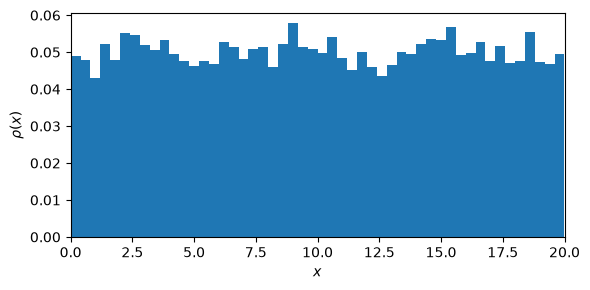

In [12]:
samples = vstate.sample()
samples = samples.reshape(-1)

plt.figure(figsize=(6, 3))
plt.hist(samples, bins=50, density=True)

plt.xlabel(r"$x$")
plt.ylabel(r"$\rho(x)$")
plt.xlim(0, L)
plt.tight_layout()

We then proceed to the optimisation as before.

In [13]:
optimizer = nk.optimizer.Sgd(learning_rate=0.02)

gs = nk.driver.VMC(
    ha,
    optimizer,
    variational_state=vstate,
    preconditioner=nk.optimizer.SR(diag_shift=0.05),
)

log = nk.logging.RuntimeLog()
gs.run(n_iter=200, out=log)

ds_energy = vstate.expect(ha)
error = abs((ds_energy.mean - 24.742) / 24.742)
print("Optimised energy and relative error: ", ds_energy, error)

  0%|                                                  | 0/200 [00:00<?, ?it/s]

Optimised energy and relative error:  24.7488 ± 0.0083 [σ²=6.9e-02, R̂=1.004] 0.00027563191743561113


### Measuring Other Properties

Once the model has been optimised, we can of start to measure other observables besides the energy. An interesting quantity could for example be the radial distribution function, which is related to the structure factor measured in scattering experiments. It is defined as

$$
g(r) = C \langle \sum_{i<j} \delta(r-x_{ij}) \rangle
$$

where $ \langle \cdot \rangle $ denotes the expectation value with respect to the probability distribution defined by the optimised wave-function. The constant $C$ is chosen such that $\int \mathrm{d}r g(r) = N(N-1)$.

To evaluate the above expression we need samples from the optimised wavefunction.

In [14]:
samples = vstate.sample(chain_length=3 * 10**4)

In [15]:
import numpy as np
import jax

def gr(samples, n_particles, sdim, L, bins=80):
    dists = minimum_distance(samples, n_particles, sdim)
    hist, bin_edges = np.histogram(dists.flatten(), bins=bins, range=(0, L / 2))
    delta_r = bin_edges[1] - bin_edges[0]
    centers = (bin_edges[1:] + bin_edges[:-1]) / 2

    gC = hist / (dists.shape[0] * n_particles)

    def get_jacobian():
        if sdim == 1:
            return np.ones_like(centers)
        elif sdim == 2:
            return 2 * np.pi * centers
        elif sdim == 3:
            return 4 * np.pi * centers**2
        else:
            raise NotImplementedError(
                f"Jacobian factor not yet implemented for sdim={sdim}"
            )

    def get_volume():
        return L**sdim

    def get_density():
        return n_particles / get_volume()

    gU = get_jacobian() * delta_r * get_density()

    return centers, gC / gU

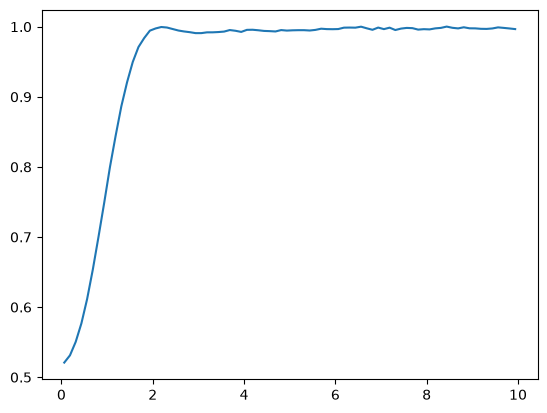

In [16]:
c, g = gr(samples, n_particles=N, sdim=dim, L=L)
plt.plot(c, g)

### Can you modify the parameters of the systems as to induce crystaline order?